In [61]:
import pandas as pd

# load dataset
df = pd.read_csv("../data/netflix_titles.csv")

# show first rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Deep Data Understanding (Start of Real EDA)

Dataset Overview

In [62]:
df.shape

(8807, 12)

In [63]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [65]:
# Only works for numeric columns

df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Dataset Understanding:

- The dataset contains Netflix titles including movies and TV shows.
- It includes information like title, director, cast, country, and release year.
- Some columns may contain missing values (e.g., director, cast).

Check Missing Values


In [66]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [67]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [68]:
df["country"].value_counts().head()

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64

Initial Observations:

- Dataset contains both Movies and TV Shows.
- Some columns like director and cast have missing values.
- Certain countries appear more frequently.

# Data Cleaning

Handle Missing Values

In [69]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Not Available")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

Fix date_added

In [70]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

Extract Year

In [71]:
df["year_added"] = df["date_added"].dt.year

In [72]:
df["year_added"].unique()

array([2021., 2020., 2019., 2018., 2017., 2016., 2015., 2014., 2013.,
       2012., 2011., 2009., 2008.,   nan, 2010.])

In [73]:
df = df.dropna(subset=["year_added"])
df["year_added"] = df["year_added"].astype(int)

Fix duration

In [ ]:
df["duration"] = df["duration"].fillna("0 min")

Verify Cleaning

In [76]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64

Data Cleaning:

- Filled missing values in director, cast, country, and rating with placeholders.
- Convert date_added to datetime format.
- Extracted year_added for time-based analysis.
- Processed duration column to extract numerical values.

Deep EDA (Real Insights + Visualizations)

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

📊 Movies vs TV Shows

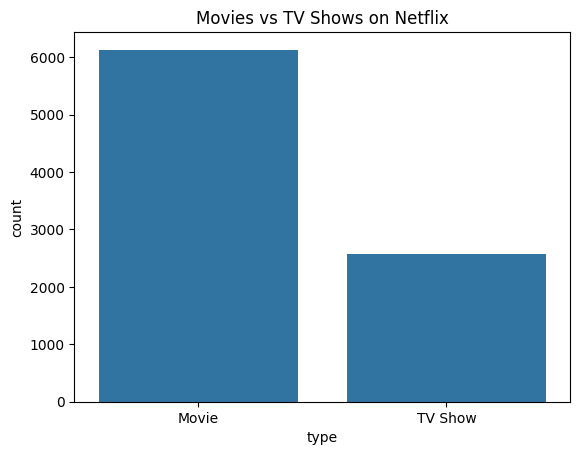

In [78]:
sns.countplot(x="type", data=df)
plt.title("Movies vs TV Shows on Netflix")
plt.show()

- Netflix has more Movies compared to TV Shows.
- Movies dominate the platform's content library.

🌍 Top Countries Producing Content

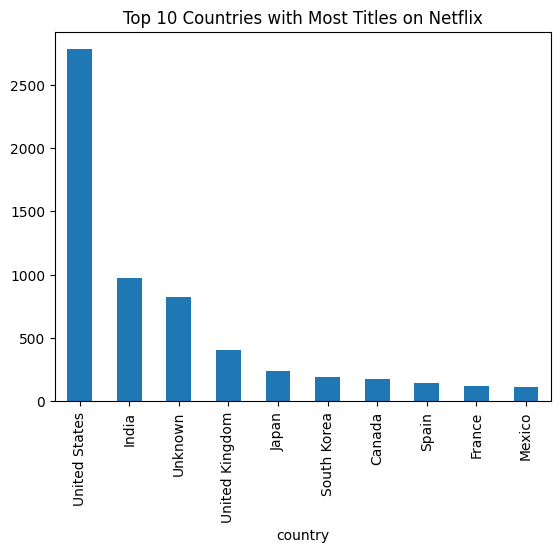

In [79]:
df["country"] .value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries with Most Titles on Netflix")
plt.show()

- United States and India are among the top contributors.
- Content production is concentrated in a few countries.

📅 Content Growth Over Time

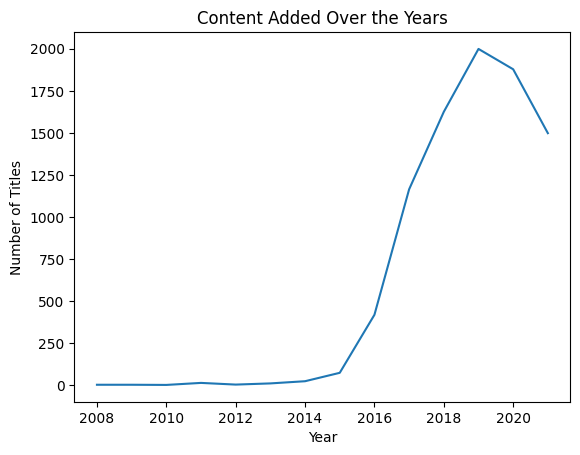

In [80]:
df["year_added"].value_counts().sort_index().plot()
plt.title("Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

- Netflix content grew slowly before 2015.
- Rapid increase in content after 2015.
- Peak content addition observed around 2019-2020.

⭐ Ratings Distribution

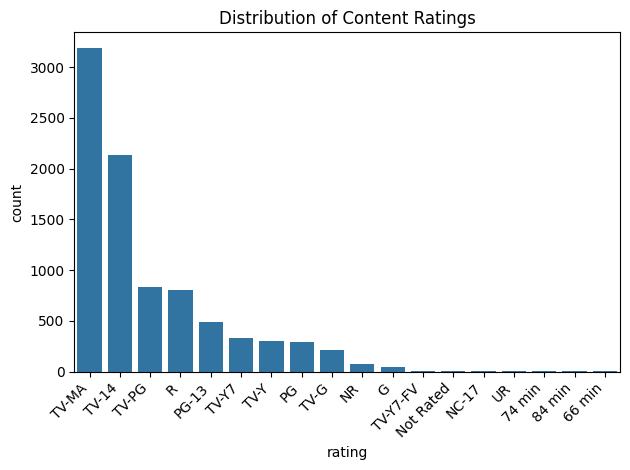

In [ ]:
sns.countplot(x="rating", data=df, order=df["rating"].value_counts().index)
plt.title("Distribution of Content Ratings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Most content is targeted towards mature audiences.
- TV-MA and TV-14 ratings dominate.

🎭 Genre Analysis

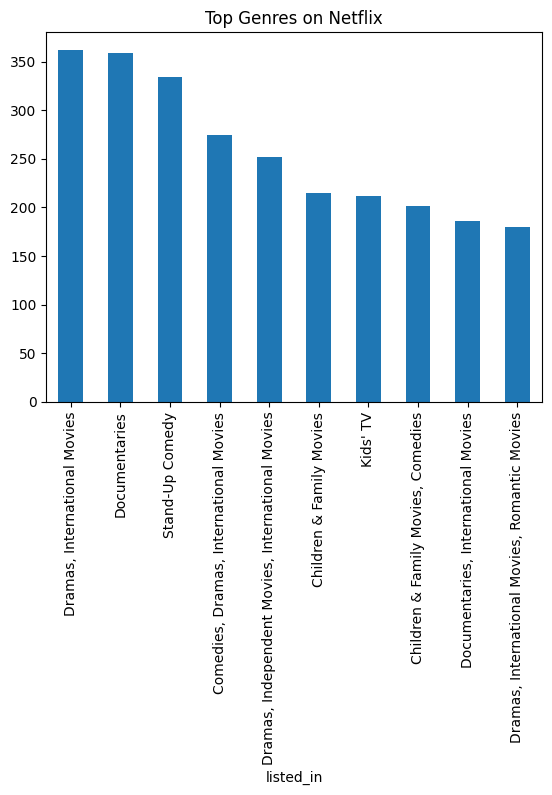

In [84]:
df["listed_in"].value_counts().head(10).plot(kind="bar")
plt.title("Top Genres on Netflix")
plt.show()

- Drama and International content are most common.
- Netflix focuses heavily on diverse global genres.

🎬 Movies Duration Analysis

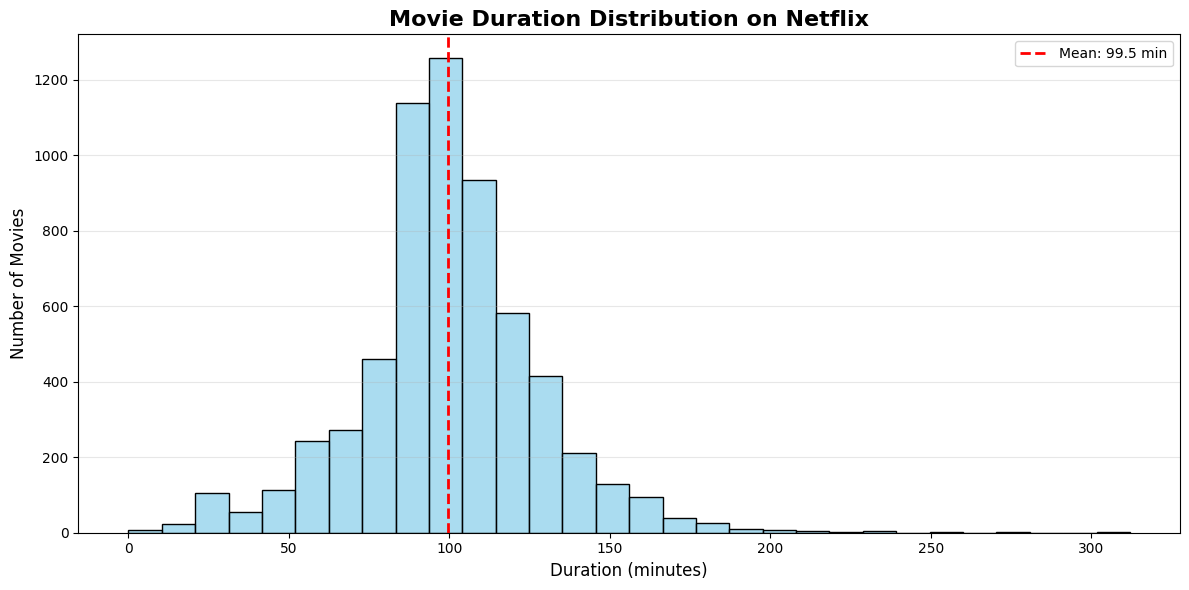

In [91]:
plt.figure(figsize=(12, 6))
sns.histplot(movie_durations, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Movie Duration Distribution on Netflix", fontsize=16, fontweight='bold')
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.axvline(movie_durations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {movie_durations.mean():.1f} min')
plt.legend()
plt.tight_layout()
plt.show()

- Most movies are between 80-120 minutes.
- Standard movie duration dominates.

# Advanced Insights (Portfolio-Level Analysis)

🧠 Movies vs TV Shows Over Time

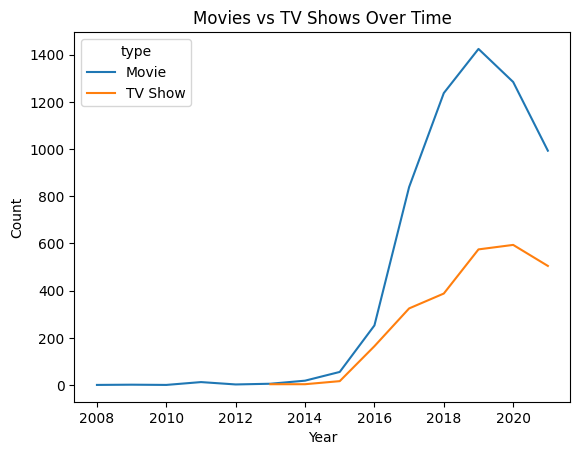

In [92]:
content_year = df.groupby(["year_added", "type"]).size().unstack()
content_year.plot()
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Count") 
plt.show()

- Movies dominate consistently across all years.
- TV Shows increased significantly after 2015.
- Netflix started investing more in series in recent years.

🌍 Top Countries for Movies vs TV Shows

In [94]:
df.groupby("country")["type"].value_counts().unstack().fillna(0).sort_values(by="Movie", ascending=False).head(10)

type,Movie,TV Show
country,,
United States,2058.0,720.0
India,893.0,78.0
Unknown,440.0,387.0
United Kingdom,206.0,197.0
Canada,122.0,51.0
Spain,97.0,44.0
Egypt,92.0,14.0
Nigeria,86.0,9.0
Indonesia,77.0,2.0


- USA dominates both Movies and TV Shows.
- Some countries focus more on specific content types.

🎬 Most Common Genres

In [95]:
df["listed_in"].str.split(", ").explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1328
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

- Drama is the most common genre.
- International content is highly popular.

⭐ Content Release Year Trend

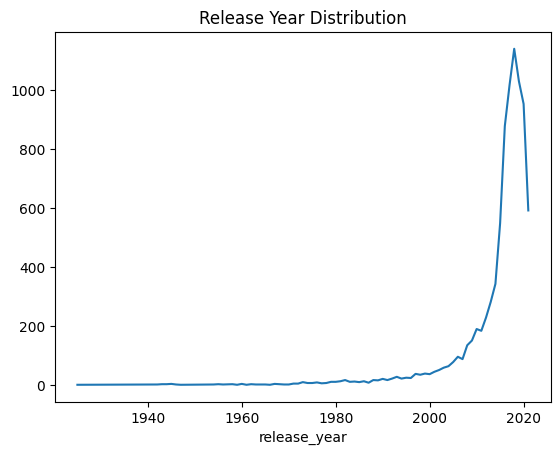

In [96]:
df["release_year"].value_counts().sort_index().plot()
plt.title("Release Year Distribution")
plt.show()

- Most content is from recent years.
- Older content exists but is limited.

🎯 Top Directors

In [98]:
df[df["director"] != "Unknown"]["director"].value_counts().head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

- Some directors contribute multiple titles.
- Many entries had missing director info (cleaned earlier).